Dataset Shape: (891, 12)

Data After Preprocessing:

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500           0           1
1         1       1    1  38.0      1      0  71.2833           0           0
2         1       3    1  26.0      0      0   7.9250           0           1
3         1       1    1  35.0      1      0  53.1000           0           1
4         0       3    0  35.0      0      0   8.0500           0           1

ENGINEERED FEATURES:

   FamilySize  IsAlone  FarePerPerson
0           2        0        3.62500
1           2        0       35.64165
2           1        1        7.92500
3           2        0       26.55000
4           1        1        8.05000

CORRELATION WITH SURVIVAL:

Sex              0.537
Fare             0.266
FarePerPerson    0.232
Parch            0.095
FamilySize       0.045
SibSp           -0.016
Embarked_Q      -0.049
Age             -0.082
Embarked_S     

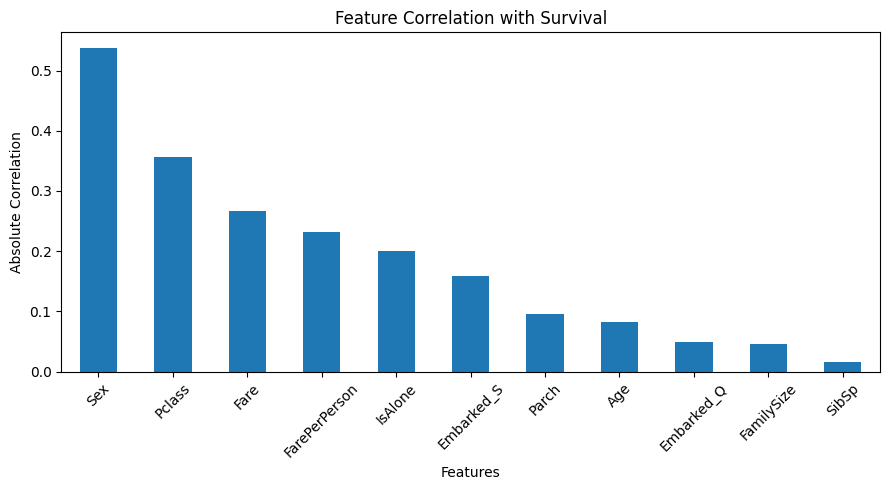


FEATURES SELECTED BY RFE:

1 . Pclass
2 . Sex
3 . Age
4 . SibSp
5 . IsAlone
6 . FarePerPerson

================ COMPARISON TABLE ================

   Metric  Before Feature Engineering  After Feature Engineering + RFE
 Accuracy                       0.797                            0.811
Precision                       0.764                            0.746
   Recall                       0.724                            0.810
 F1 Score                       0.743                            0.777


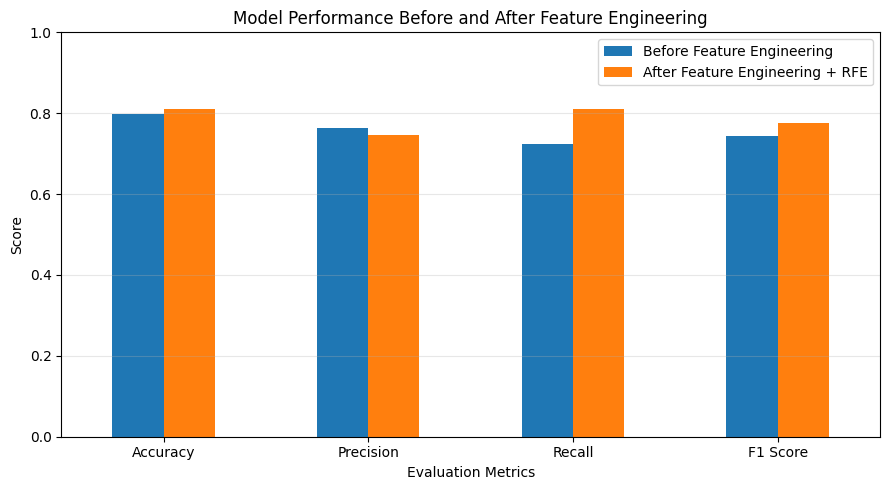

Baseline F1 Score : 0.743
Final F1 Score    : 0.777


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset Shape:", df.shape)

df = df[
    [   "Survived",
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"]]
df = df.dropna().copy()

df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1})

df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True,
    dtype=int)

print("\nData After Preprocessing:\n")
print(df.head())

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42)
baseline_model.fit(
    X_train_scaled,
    y_train)
y_pred = baseline_model.predict(
    X_test_scaled)
accuracy_before = accuracy_score(
    y_test,
    y_pred)
precision_before = precision_score(
    y_test,
    y_pred,
    zero_division=0)
recall_before = recall_score(
    y_test,
    y_pred,
    zero_division=0)
f1_before = f1_score(
    y_test,
    y_pred,
    zero_division=0)

df["FamilySize"] = (
    df["SibSp"] +
    df["Parch"] + 1)

df["IsAlone"] = (
    df["FamilySize"] == 1).astype(int)

df["FarePerPerson"] = (
    df["Fare"] /
    df["FamilySize"])

print("\nENGINEERED FEATURES:\n")
print(
    df[["FamilySize",
        "IsAlone",
        "FarePerPerson"]].head())
X_new = df.drop("Survived", axis=1)
y_new = df["Survived"]
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.20,
    random_state=42,
    stratify=y_new)
correlation = (
    df.corr(numeric_only=True)["Survived"]
    .drop("Survived")
    .sort_values(
        ascending=False))

print("\nCORRELATION WITH SURVIVAL:\n")

print(correlation.round(3))
plt.figure(figsize=(9, 5))
correlation.abs().sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Correlation with Survival")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

scaler_new = StandardScaler()
X_train_new_scaled = scaler_new.fit_transform(X_train_new)
X_test_new_scaled = scaler_new.transform(X_test_new)
rfe_model = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(estimator=rfe_model, n_features_to_select=6)
rfe.fit(X_train_new_scaled,y_train_new)
selected_features = X_new.columns[rfe.support_]
print("\nFEATURES SELECTED BY RFE:\n")
for i, feature in enumerate(selected_features, 1):print(i, ".", feature)

X_train_selected = (X_train_new_scaled[:, rfe.support_])
X_test_selected = (X_test_new_scaled[:, rfe.support_])
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_selected,y_train_new)

y_pred_final = final_model.predict(X_test_selected)
accuracy_after = accuracy_score(y_test_new, y_pred_final)
precision_after = precision_score(y_test_new, y_pred_final, zero_division=0)
recall_after = recall_score(y_test_new, y_pred_final, zero_division=0)
f1_after = f1_score(y_test_new, y_pred_final, zero_division=0)

results = pd.DataFrame({
        "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"],
    "Before Feature Engineering": [
        accuracy_before,
        precision_before,
        recall_before,
        f1_before],
    "After Feature Engineering + RFE": [
        accuracy_after,
        precision_after,
        recall_after,
        f1_after]})

print("\n================ COMPARISON TABLE ================\n")
print(results.round(3).to_string(index=False))
results_plot = results.set_index("Metric")
results_plot.plot(kind="bar", figsize=(9, 5))

plt.title("Model Performance Before and After Feature Engineering")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Baseline F1 Score :", round(f1_before, 3))
print("Final F1 Score    :", round(f1_after, 3))